# $\texttt{Note}$
- 该脚本总体上内容较多较为复杂
- 不过，RR Single Neuron Version可以不用管
- 在Cluster Neurons Version中，因为曾经尝试了许多种“提升效果的办法”，所以会有相当多种实现选项。

## RR Single Neuron Version

In [1]:
import numpy as np
import torch
import torch.nn as nn
from pykeen.datasets import Nations
from collections import defaultdict
from typing import List, Tuple, Dict, Set

class ThreeLayerBriefNeuralNetwork:
    """
    三层仿脑神经网络模型用于知识图谱补全（Nations数据集）
    
    结构说明：
    - 第一层(α): Entity层，对应国家，无层内连接
    - 第二层(β): Relational Reasoning层，对应国家，有层内权重W_{β,β}，可分出Cluster
    - 第三层(γ): Relation Cluster层，对应关系，有层内权重W_{γ,γ}
    
    连接权重：
    - W_{(γ,β)}: γ到β的连接
    - W_{(β,γ)}: β到γ的连接
    - W_{(β,β)}: β层内连接
    - W_{(γ,γ)}: γ层内连接
    """
    
    def __init__(self, num_entities: int, num_relations: int, theta: float = 0.5, threshold: float = 0.5):
        """
        初始化模型参数
        
        Args:
            num_entities: 国家个数（α和β层的神经元个数）
            num_relations: 关系个数（γ层的神经元个数）
            theta: γ层权重更新的超参数
            threshold: 推理时的阈值T，用于选择相关关系
        """
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.theta = theta
        self.threshold = threshold
        
        # α层：实体层，仅用于索引映射，无需存储神经元（与β层一一对应）
        
        # β层内连接权重矩阵 W_{β,β} (num_entities × num_entities)
        self.W_beta_beta = np.zeros((num_entities, num_entities))
        
        # γ层内连接权重矩阵 W_{γ,γ} (num_relations × num_relations)
        self.W_gamma_gamma = np.zeros((num_relations, num_relations))
        
        # β层与γ层间的连接权重
        # W_{γ,β}: γ到β的连接 (num_relations × num_entities)
        self.W_gamma_to_beta = np.zeros((num_relations, num_entities))
        
        # W_{β,γ}: β到γ的连接 (num_entities × num_relations)
        self.W_beta_to_gamma = np.zeros((num_entities, num_relations))
        
        # 用于存储训练数据中的三元组，用于后续学习
        self.triplets = []  # List of (h_idx, r_idx, t_idx)
        
    def learn_from_triplet(self, h_idx: int, r_idx: int, t_idx: int):
        """
        根据训练三元组 (h_i, r_j, t_k) 更新权重
        
        学习规则：
        1. W_{γ_j, β_i} = 1（从relation γ_j 到head对应的β_i）
        2. W_{β_k, γ_j} = 1（从tail对应的β_k 到relation γ_j）
        3. 更新γ层内权重：对于相同(h,t)但不同r的情况
        
        Args:
            h_idx: head实体索引
            r_idx: 关系索引
            t_idx: tail实体索引
        """
        # 规则1 & 2: γ到β和β到γ的权重设为1
        self.W_gamma_to_beta[r_idx, h_idx] = 1.0
        self.W_beta_to_gamma[t_idx, r_idx] = 1.0
        
        # 存储三元组用于后续学习
        self.triplets.append((h_idx, r_idx, t_idx))
        
        # 规则3: 更新γ层内权重（基于相同head和tail的不同relation）
        # 找出所有具有相同(h,t)但不同r的三元组
        for i, (h_i, r_q, t_i) in enumerate(self.triplets):
            if h_i == h_idx and t_i == t_idx and r_q != r_idx:
                # 对于这样的三元组对，更新γ层内权重
                self.W_gamma_gamma[r_idx, r_q] += self.theta
                self.W_gamma_gamma[r_q, r_idx] += self.theta
    
    def infer(self, h_idx: int, r_idx: int) -> Dict[int, float]:
        """
        给定(h_i, r_j, ?)进行推理，预测tail实体及其得分
        
        推理过程：
        1. 找出所有满足 W_{γ_j, γ_p} >= threshold 的relation γ_p
        2. 对每个这样的relation γ_p，从其投射得到国家集合 Β_p
        3. 对每个国家β_k计算得分：Score(β_k) = Σ W_{γ_j, γ_q}（如果β_k ∈ Β_q）
        
        Args:
            h_idx: head实体索引
            r_idx: 查询关系索引
            
        Returns:
            字典，键为实体索引，值为预测得分
        """
        scores = {}
        
        # 步骤1: 找出阈值内的相关关系
        # W_{γ_j, γ_p} >= threshold 的所有γ_p
        related_relations = []
        for gamma_p in range(self.num_relations):
            if self.W_gamma_gamma[r_idx, gamma_p] >= self.threshold:
                related_relations.append(gamma_p)
        
        # 如果没有找到相关关系，至少包含查询关系本身
        if not related_relations:
            related_relations.append(r_idx)
        
        # 步骤2 & 3: 对每个相关关系，找出对应的国家并计算得分
        for gamma_q in related_relations:
            # 从γ_q投射得到的β集合（β to γ权重非零的β）
            beta_set = []
            for beta_k in range(self.num_entities):
                # 检查是否存在从β_k通往某个关系的路径
                # 具体：W_{β_k, γ_q}是否非零（来自训练）
                if self.W_beta_to_gamma[beta_k, gamma_q] > 0:
                    beta_set.append(beta_k)
            
            # 计算在Β_q中的国家的得分
            weight = self.W_gamma_gamma[r_idx, gamma_q]
            for beta_k in beta_set:
                if beta_k not in scores:
                    scores[beta_k] = 0
                scores[beta_k] += weight
        
        # 如果没有从其他关系得到预测，尝试直接从head投射
        if not scores:
            # 从W_{γ_j, β_i}找可达的tail
            for beta_k in range(self.num_entities):
                if self.W_gamma_to_beta[r_idx, h_idx] > 0:
                    # 这条路径存在，对所有有connection的tail都给分
                    for t_idx in range(self.num_entities):
                        if self.W_beta_to_gamma[t_idx, r_idx] > 0:
                            if t_idx not in scores:
                                scores[t_idx] = 0
                            scores[t_idx] += 1.0
        
        return scores
    
    def get_entity_clusters_from_beta(self) -> Dict[int, List[int]]:
        """
        从β层内权重W_{β,β}找出Country Cluster
        
        Returns:
            字典，键为cluster id，值为cluster中的entity列表
        """
        # 这里可以基于W_{β,β}进行聚类分析
        # 当前简化：权重较大的connection认为属于同一cluster
        clusters = defaultdict(list)
        
        # 简单聚类：根据connection权重阈值
        visited = set()
        for i in range(self.num_entities):
            if i not in visited:
                cluster = [i]
                visited.add(i)
                for j in range(i + 1, self.num_entities):
                    if j not in visited and self.W_beta_beta[i, j] > 0.1:
                        cluster.append(j)
                        visited.add(j)
                clusters[len(clusters)] = cluster
        
        return dict(clusters)


def load_nations_data():
    """
    从PyKEEN加载Nations数据集
    
    Returns:
        dataset: PyKEEN Nations数据集
        entity_to_id: 实体标签到ID的映射字典
        relation_to_id: 关系标签到ID的映射字典
    """
    # 加载Nations数据集
    dataset = Nations()
    
    # 获取实体和关系的标签到ID的映射（PyKEEN API）
    entity_to_id = dataset.entity_to_id
    relation_to_id = dataset.relation_to_id
    
    print(f"实体总数: {len(entity_to_id)}")
    print(f"关系总数: {len(relation_to_id)}")
    print(f"实体列表: {list(entity_to_id.keys())}")
    
    return dataset, entity_to_id, relation_to_id


def convert_triplets_to_indices(dataset, entity_to_id: Dict, relation_to_id: Dict) -> Tuple[List, List, List]:
    """
    将PyKEEN数据集的三元组转换为索引形式
    
    Args:
        dataset: PyKEEN Nations数据集
        entity_to_id: 实体标签到ID的映射
        relation_to_id: 关系标签到ID的映射
        
    Returns:
        train_triplets, valid_triplets, test_triplets: 索引形式的三元组列表
    """
    def convert_set(triples):
        converted = []
        for triple in triples:
            h_label, r_label, t_label = triple
            h_idx = entity_to_id[h_label]
            r_idx = relation_to_id[r_label]
            t_idx = entity_to_id[t_label]
            converted.append((h_idx, r_idx, t_idx))
        return converted
    
    train_triplets = convert_set(dataset.training.triples)
    valid_triplets = convert_set(dataset.validation.triples)
    test_triplets = convert_set(dataset.testing.triples)
    
    print(f"\n训练集三元组数: {len(train_triplets)}")
    print(f"验证集三元组数: {len(valid_triplets)}")
    print(f"测试集三元组数: {len(test_triplets)}")
    
    return train_triplets, valid_triplets, test_triplets


/home/amax/miniconda3/envs/nvembed/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===========================
# 训练和测试阶段
# ===========================

# 第一步：加载数据集
print("="*60)
print("1. 加载Nations数据集")
print("="*60)
dataset, entity_to_id, relation_to_id = load_nations_data()

# 第二步：转换为索引形式
print("\n" + "="*60)
print("2. 转换三元组为索引形式")
print("="*60)
train_triplets, valid_triplets, test_triplets = convert_triplets_to_indices(
    dataset, entity_to_id, relation_to_id
)

# 获取ID到标签的反向映射
id_to_entity = {v: k for k, v in entity_to_id.items()}
id_to_relation = {v: k for k, v in relation_to_id.items()}

# 打印一些示例三元组
print("\n训练集前5个三元组（索引形式）:")
for i, (h, r, t) in enumerate(train_triplets[:5]):
    h_label = id_to_entity[h]
    r_label = id_to_relation[r]
    t_label = id_to_entity[t]
    print(f"  {i+1}. ({h_label}, {r_label}, {t_label})")

# 第三步：初始化模型
print("\n" + "="*60)
print("3. 初始化三层神经网络模型")
print("="*60)
num_entities = len(entity_to_id)
num_relations = len(relation_to_id)
theta = 0.5  # 可调超参
threshold = 0.1  # 推理时的阈值

model = ThreeLayerBriefNeuralNetwork(
    num_entities=num_entities,
    num_relations=num_relations,
    theta=theta,
    threshold=threshold
)
print(f"模型初始化完成")
print(f"  - Entity层(α): {num_entities}个神经元")
print(f"  - RR层(β): {num_entities}个神经元（层内权重阵维度: {num_entities}×{num_entities}）")
print(f"  - RC层(γ): {num_relations}个神经元（层内权重阵维度: {num_relations}×{num_relations}）")
print(f"  - 超参θ: {theta}")
print(f"  - 推理阈值T: {threshold}")

# 第四步：训练（学习过程）
print("\n" + "="*60)
print("4. 训练阶段：学习权重")
print("="*60)

# 根据训练集更新权重
for iteration, (h_idx, r_idx, t_idx) in enumerate(train_triplets):
    model.learn_from_triplet(h_idx, r_idx, t_idx)
    if (iteration + 1) % max(1, len(train_triplets) // 5) == 0:
        print(f"  已处理三元组: {iteration + 1}/{len(train_triplets)}")

print(f"\n权重矩阵学习完成：")
print(f"  - W_{{β,β}}非零元素个数: {np.count_nonzero(model.W_beta_beta)}")
print(f"  - W_{{γ,γ}}非零元素个数: {np.count_nonzero(model.W_gamma_gamma)}")
print(f"  - W_{{γ→β}}非零元素个数: {np.count_nonzero(model.W_gamma_to_beta)}")
print(f"  - W_{{β→γ}}非零元素个数: {np.count_nonzero(model.W_beta_to_gamma)}")

# 打印γ层权重矩阵（γ到γ的连接，表示关系间的关系）
print(f"\nW_{{γ,γ}}矩阵（关系间的连接权重，仅显示非零元素）:")
print("关系索引和标签:")
for idx in range(num_relations):
    print(f"  索引{idx}: {id_to_relation[idx]}", end="")
    if (idx + 1) % 3 == 0:
        print()
    else:
        print(" | ", end="")

print("\n\nW_{{γ,γ}}非零元素:")
for i in range(num_relations):
    for j in range(i, num_relations):
        if model.W_gamma_gamma[i, j] > 0:
            print(f"  W[{id_to_relation[i]}, {id_to_relation[j]}] = {model.W_gamma_gamma[i, j]:.4f}")

# 第五步：测试评估
print("\n" + "="*60)
print("5. 测试阶段：评估性能")
print("="*60)

def evaluate_predictions(model, test_triplets, id_to_entity, num_entities, k: List[int] = [1, 3, 10]):
    """
    评估模型在测试集上的性能
    
    指标：
    - Hits@k: 前k个预测中包含正确答案的比例
    - MRR: Mean Reciprocal Rank，平均倒数排名
    - MR: Mean Rank，平均排名
    
    Args:
        model: 三层神经网络模型
        test_triplets: 测试三元组列表
        id_to_entity: ID到实体标签的映射
        num_entities: 实体总数
        k: Hits@k中的k值列表
        
    Returns:
        评估结果字典
    """
    hits_at_k = {ki: 0 for ki in k}
    mrr = 0
    mr = 0
    
    num_test = len(test_triplets)
    
    for test_idx, (h_idx, r_idx, t_idx) in enumerate(test_triplets):
        # 进行推理预测
        predictions = model.infer(h_idx, r_idx)
        
        # 将预测结果按得分排序
        sorted_pred = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        
        # 如果没有任何预测，跳过此样本或给所有实体相同的分数
        if not sorted_pred:
            sorted_pred = [(ent_idx, 0) for ent_idx in range(num_entities)]
        
        # 计算排名
        rank = None
        for rank_pos, (pred_ent_idx, score) in enumerate(sorted_pred, 1):
            if pred_ent_idx == t_idx:
                rank = rank_pos
                break
        
        # 如果正确答案不在预测中，排名为最后
        if rank is None:
            rank = num_entities
        
        # 更新指标
        mr += rank
        mrr += 1.0 / rank
        
        for ki in k:
            if rank <= ki:
                hits_at_k[ki] += 1
        
        if (test_idx + 1) % max(1, num_test // 5) == 0:
            print(f"  已评估: {test_idx + 1}/{num_test}")
    
    # 计算平均值
    results = {
        'MR': mr / num_test,
        'MRR': mrr / num_test,
    }
    for ki in k:
        results[f'Hits@{ki}'] = (hits_at_k[ki] / num_test) * 100  # 转换为百分比
    
    return results

# 运行评估
print("评估模型性能...")
results = evaluate_predictions(
    model, 
    test_triplets, 
    id_to_entity,
    num_entities,
    k=[1, 3, 10]
)

print("\n" + "="*60)
print("测试结果汇总")
print("="*60)
print(f"Mean Rank (MR): {results['MR']:.4f}")
print(f"Mean Reciprocal Rank (MRR): {results['MRR']:.4f}")
print(f"Hits@1: {results['Hits@1']:.2f}%")
print(f"Hits@3: {results['Hits@3']:.2f}%")
print(f"Hits@10: {results['Hits@10']:.2f}%")

# 第六步：示例推理
print("\n" + "="*60)
print("6. 示例推理：具体案例演示")
print("="*60)

# 选择几个测试样本进行详细推理展示
num_examples = min(3, len(test_triplets))
for example_idx in range(num_examples):
    h_idx, r_idx, t_idx = test_triplets[example_idx]
    h_label = id_to_entity[h_idx]
    r_label = id_to_relation[r_idx]
    t_label = id_to_entity[t_idx]
    
    print(f"\n示例{example_idx + 1}: ({h_label}, {r_label}, ?)")
    print(f"正确答案: {t_label}")
    
    # 进行推理
    predictions = model.infer(h_idx, r_idx)
    
    if predictions:
        # 按得分排序并显示Top-3预测
        sorted_pred = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:3]
        print("Top-3预测:")
        for rank, (pred_ent_idx, score) in enumerate(sorted_pred, 1):
            pred_label = id_to_entity[pred_ent_idx]
            correct = "✓" if pred_ent_idx == t_idx else ""
            print(f"  Rank {rank}: {pred_label} (得分: {score:.4f}) {correct}")
    else:
        print("  未生成任何预测")

print("\n" + "="*60)
print("完成！")
print("="*60)


Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


1. 加载Nations数据集
实体总数: 14
关系总数: 55
实体列表: ['brazil', 'burma', 'china', 'cuba', 'egypt', 'india', 'indonesia', 'israel', 'jordan', 'netherlands', 'poland', 'uk', 'usa', 'ussr']

2. 转换三元组为索引形式

训练集三元组数: 1592
验证集三元组数: 199
测试集三元组数: 201

训练集前5个三元组（索引形式）:
  1. (brazil, blockpositionindex, china)
  2. (brazil, blockpositionindex, cuba)
  3. (brazil, blockpositionindex, poland)
  4. (brazil, blockpositionindex, ussr)
  5. (brazil, booktranslations, uk)

3. 初始化三层神经网络模型
模型初始化完成
  - Entity层(α): 14个神经元
  - RR层(β): 14个神经元（层内权重阵维度: 14×14）
  - RC层(γ): 55个神经元（层内权重阵维度: 55×55）
  - 超参θ: 0.5
  - 推理阈值T: 0.1

4. 训练阶段：学习权重
  已处理三元组: 318/1592
  已处理三元组: 636/1592
  已处理三元组: 954/1592
  已处理三元组: 1272/1592
  已处理三元组: 1590/1592

权重矩阵学习完成：
  - W_{β,β}非零元素个数: 0
  - W_{γ,γ}非零元素个数: 2344
  - W_{γ→β}非零元素个数: 471
  - W_{β→γ}非零元素个数: 438

W_{γ,γ}矩阵（关系间的连接权重，仅显示非零元素）:
关系索引和标签:
  索引0: accusation |   索引1: aidenemy |   索引2: attackembassy
  索引3: blockpositionindex |   索引4: booktranslations |   索引5: boycottembargo
  索引6: commonbloc0 | 

## RR Cluster Neurons Version
超参数整理：

在 **RR Cluster Neurons Version** 中，模型通过多项超参数的调整，探索了不同网络连接机制、评分机制及表征维度对知识图谱补全的影响。主要超参数总结如下：

### 1. 基础网络超参数
* **`theta` ($\theta$)**：Hebbian 学习率。在 `learning_version=1` 时，控制不同关系发生共现时，对 $\gamma$ 层内部连接权重矩阵 $W_{\gamma\gamma}$ 的累加步长。
* **`T`**：关系聚簇推理的连接阈值。在测试推理阶段，只有当两种关系之间的共现权重 $W_{\gamma\gamma}[r_{idx}, r_p] \ge T$ 时，$r_{idx}$ 的激活信号才能向外传递给关系 $r_p$。
* **`activation`**：基于 $\beta$ 层的激活函数，决定了神经元局部关联信号传播的非线性变换方式。包含 `sigmoid`、`step`、`relu` 等选项。
* **`thresh`**：激活函数的触发阈值（仅在 `step` 和 `relu` 时生效）。决定了接收到的累加信号必须多强才能使当前神经元被激活或释放残余值。

### 2. 学习方式与权重构建超参数
* **`learning_version`**：
  * **`1`**: 传统的基于**共现频次**累加构建 $W_{\gamma\gamma}$ 矩阵（受步长 $\theta$ 影响）。
  * **`2`**: 基于 **PMI (Pointwise Mutual Information)** 动态计算关系共现强度。它从全局统计角度出发，消除热门关系的频繁共现噪音，是一种更加科学且无需手动微调 $\theta$ 的建边方式。

### 3. 评分函数超参数
* **`score_version`**：决定在普通前馈推理时最终选取 Target 实体的方法：
  * **`0`**: 原始累加打分。
  * **`1`**: 引入 **IRF (Inverse Relation Frequency)** 制约，稀有关系的对应实体会获得更高的权重奖励。
  * **`2`**: 引入 IRF 加上 **Relation Group Size** 的联合约束，进一步惩罚活跃度过高（拥有过多关系连接）的实体，以排除“万金油”实体的干扰。

### 4. 模式感知与匹配超参数 (h_r_detect)
`h_r_detect` 决定了是否使用基于特定子矩阵/子向量特征模式的实体匹配策略。模型假定：
$$
\mathbf{C}_{(\alpha^k,\gamma_j)} = \frac{1}{n} \sum_{i=1}^n \boldsymbol{v}^{i}
$$
其中集合内包含已知属于该目标国模式的其它邻国向量$\boldsymbol{v}^i$，最终使用余弦相似度匹配得分。

* **`h_r_detect = 0`**: 关闭匹配提取机制，退回普通的三层网络前馈传播进行目标打分。
* **`h_r_detect = 1`（Wrong Version One）**: 
  提取已知 Target 实体在 **所有关系** 下的出度特征。具体是对 $W_{\beta\beta}$ 矩阵中属于目标实体的 $M$个列进行展平，得到大小为 $(N \times M)$ 的子特征提取作为 $\boldsymbol{v}^i$。虽然包含了被 $\gamma_j$ 激发的响应，但也混入并展平了大量非必须的其他关系的总体影响。
* **`h_r_detect = 2`（精简&对应特定Relation）**:
  只针对**特定关系** $\gamma_j$，准确提取该国家通过 $\gamma_j$ 作用于其他 $N$ 个国家的向量，兼顾受到其它 $N$ 个国家利用 $\gamma_j$ 作用的特征：
  1. 通过该国触发 $\gamma_j$ ，并激活其他国家的神经元得到大小为 $N \times 1$ 的 出度向量 $\mathbf{C}_{(\alpha^k,\gamma_j)}$。
  2. 被其他国家触发 $\gamma_j$ 作用到本身的入度向量 $\mathbf{C'}_{(\alpha^k,\gamma_j)}$。
  提取这两个大小为 $N \times 1$ 的向量并拼接成长为 $2N$ 的向量作为最终的表征指纹 $\boldsymbol{v}^i$，准确评估具有特定同构关联的 Tail Entity 特征。

### 基础函数定义

In [3]:
import numpy as np
import torch
import torch.nn as nn
from pykeen.datasets import Nations
from collections import defaultdict
from typing import List, Tuple, Dict, Set

def load_nations_data():
    dataset = Nations()
    entity_to_id = dataset.entity_to_id
    relation_to_id = dataset.relation_to_id
    print(f"实体总数: {len(entity_to_id)}")
    print(f"关系总数: {len(relation_to_id)}")
    return dataset, entity_to_id, relation_to_id

def convert_triplets_to_indices(dataset, entity_to_id: Dict, relation_to_id: Dict) -> Tuple[List, List, List]:
    def convert_set(triples):
        converted = []
        for triple in triples:
            h_label, r_label, t_label = triple
            h_idx = entity_to_id[h_label]
            r_idx = relation_to_id[r_label]
            t_idx = entity_to_id[t_label]
            converted.append((h_idx, r_idx, t_idx))
        return converted
    
    train_triplets = convert_set(dataset.training.triples)
    valid_triplets = convert_set(dataset.validation.triples)
    test_triplets = convert_set(dataset.testing.triples)
    
    print(f"训练集三元组数: {len(train_triplets)}")
    print(f"验证集三元组数: {len(valid_triplets)}")
    print(f"测试集三元组数: {len(test_triplets)}")
    
    return train_triplets, valid_triplets, test_triplets

def evaluate_predictions(model, test_triplets, id_to_entity, num_entities, k: List[int] = [1, 3, 10], score_version: int = 1, h_r_detect: int = 0):
    hits_at_k = {ki: 0 for ki in k}
    mrr = 0
    mr = 0
    
    num_test = len(test_triplets)
    
    for test_idx, (h_idx, r_idx, t_idx) in enumerate(test_triplets):
        predictions = model.infer(h_idx, r_idx, score_version=score_version, h_r_detect=h_r_detect)
        sorted_pred = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        
        if not sorted_pred:
            sorted_pred = [(ent_idx, 0) for ent_idx in range(num_entities)]
            
        rank = None
        for rank_pos, (pred_ent_idx, score) in enumerate(sorted_pred, 1):
            if pred_ent_idx == t_idx:
                rank = rank_pos
                break
                
        if rank is None:
            rank = num_entities
            
        mr += rank
        mrr += 1.0 / rank
        
        for ki in k:
            if rank <= ki:
                hits_at_k[ki] += 1
                
    results = {
        'MR': mr / num_test,
        'MRR': mrr / num_test,
    }
    for ki in k:
        results[f'Hits@{ki}'] = (hits_at_k[ki] / num_test) * 100
        
    return results

class RRClusterNeuronsNetwork:
    """
    三层仿脑神经网络模型用于知识图谱补全（RR Cluster Neurons Version）
    
    结构说明：
    - 第一层(α): Entity层，对应国家。
    - 第二层(β): Relational Reasoning层，对应特定国家与特定关系的神经元，尺寸为 N × M。
    - 第三层(γ): Relation Cluster层，对应具体关系，尺寸为 M。
    """
    
    def __init__(self, num_entities: int, num_relations: int, theta: float = 0.5, T: float = 0.5, activation: str = 'sigmoid', thresh: float = 0.5, learning_version: int = 1):
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.theta = theta
        self.T = T
        self.activation = activation
        self.thresh = thresh
        self.learning_version = learning_version
        
        # β层内连接权重 W_{ββ} (N*M × N*M)
        self.W_beta_beta = np.zeros((num_entities * num_relations, num_entities * num_relations))
        
        # γ层内连接权重 W_{γγ} (M × M)
        self.W_gamma_gamma = np.zeros((num_relations, num_relations))
        
        # β到γ和γ到β的层间连接
        self.W_gamma_to_beta = np.zeros((num_relations, num_entities, num_relations)) 
        self.W_beta_to_gamma = np.zeros((num_entities, num_relations, num_relations))
        
        self.triplets = []
        self.irf = {}
        self.relation_group_size = {}
        
    def compute_statistics(self):
        """预计算 IRF 与 RelationGroup Size, 若 learning_version=2 也在此处计算 PMI"""
        if self.learning_version == 2:
            ht_to_relations = defaultdict(set)
            for h, r, t in self.triplets:
                ht_to_relations[(h, t)].add(r)
                
            N_total = len(ht_to_relations)
            C_r = defaultdict(int)
            C_r_r = defaultdict(int)
            
            for ht, relations in ht_to_relations.items():
                for r in relations:
                    C_r[r] += 1
                relations_list = list(relations)
                for i in range(len(relations_list)):
                    for j in range(i+1, len(relations_list)):
                        r1 = relations_list[i]
                        r2 = relations_list[j]
                        C_r_r[(r1, r2)] += 1
                        C_r_r[(r2, r1)] += 1
                        
            # 计算 PMI 并更新 W_gamma_gamma
            for r_i in range(self.num_relations):
                for r_j in range(self.num_relations):
                    if r_i != r_j:
                        if C_r_r[(r_i, r_j)] > 0:
                            pmi = np.log((C_r_r[(r_i, r_j)] * N_total) / (C_r[r_i] * C_r[r_j]))
                            self.W_gamma_gamma[r_i, r_j] = max(0.0, pmi)
                        else:
                            self.W_gamma_gamma[r_i, r_j] = 0.0

        # === 预计算 IRF ===
        relation_t_counts = {r: set() for r in range(self.num_relations)}
        for (h, r, t) in self.triplets:
            relation_t_counts[r].add(t)
            
        N = self.num_entities
        for r in range(self.num_relations):
            count_r_q = len(relation_t_counts[r])
            self.irf[r] = np.log(N / (1 + count_r_q))
            
        # === 预计算 RelationGroup Size ===
        entity_relations = {e: set() for e in range(self.num_entities)}
        for (h, r, t) in self.triplets:
            entity_relations[h].add(r)
            entity_relations[t].add(r)
            
        for e in range(self.num_entities):
            self.relation_group_size[e] = max(1, len(entity_relations[e]))
        self.W_beta_beta_T = self.W_beta_beta.T
        
    def _vec_index(self, entity_idx: int, relation_idx: int) -> int:
        """获取(实体, 关系)神经元在vec(β)中的索引"""
        return relation_idx * self.num_entities + entity_idx
        
    def learn_from_triplet(self, h_idx: int, r_idx: int, t_idx: int):
        self.triplets.append((h_idx, r_idx, t_idx))
        
        # 更新β层内连接 W_{β^B_j, β^A_j} = 1
        idx_from = self._vec_index(h_idx, r_idx)
        idx_to = self._vec_index(t_idx, r_idx)
        self.W_beta_beta[idx_to, idx_from] = 1.0  # β_j^A -> β_j^B
        
        # Learning Version 1 原始的共现累计
        if self.learning_version == 1:
            for i, (h_i, r_q, t_i) in enumerate(self.triplets[:-1]):
                if h_i == h_idx and t_i == t_idx and r_q != r_idx:
                    self.W_gamma_gamma[r_idx, r_q] += self.theta
                    self.W_gamma_gamma[r_q, r_idx] += self.theta

    def apply_activation(self, z):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif self.activation == 'step':
            return np.where(z >= self.thresh, 1.0, 0.0)
        elif self.activation == 'relu':
            return np.maximum(0.0, z - self.thresh)
        return z
        
    def infer(self, h_idx: int, r_idx: int, score_version: int = 1, h_r_detect: int = 0) -> dict:
        scores = {}
        
        # 寻找训练集中含有(h_idx, r_idx)的已知目标实体 t
        t_known = [t for (h, r, t) in self.triplets if h == h_idx and r == r_idx]
        
        if h_r_detect == 1 and len(t_known) > 0:
            # 提取每个国家的 v^i (即从该国家出发的子矩阵)
            # 在 vec(beta) 中该国家的下标是 [r * N + ent_idx for r in range(M)]
            def get_V(ent_idx):
                indices = [r * self.num_entities + ent_idx for r in range(self.num_relations)]
                # 取 W_beta_beta 中所有 out-going 的权重列，flatten 成向量代表发起的所有逻辑影响
                return self.W_beta_beta[:, indices].flatten()

            V_known = [get_V(t) for t in t_known]
            C = np.mean(V_known, axis=0)
            
            # 使用基于 C 的余弦相似度计算得分（相似度越高得分越高）
            norm_C = np.linalg.norm(C)
            for k in range(self.num_entities):
                V_k = get_V(k)
                norm_V = np.linalg.norm(V_k)
                if norm_V == 0 or norm_C == 0:
                    sim = 0.0
                else:
                    sim = np.dot(V_k, C) / (norm_V * norm_C)
                scores[k] = sim
            return scores
            
        elif h_r_detect == 2 and len(t_known) > 0:
            # 提取给定 Relation r_j 下，该国通过 r_j 作用于其他N国的向量(Nx1) 及被其他N国用 r_j 作用的向量(Nx1)
            def get_V_N(ent_idx):
                # 出发方（特定国家的特定关系 r_idx 神经元）
                source_idx = self._vec_index(ent_idx, r_idx)
                # 接收方（所有其他 N 个国家该特定关系 r_idx 神经元）
                target_indices = [self._vec_index(i, r_idx) for i in range(self.num_entities)]
                
                # V_out: ent_idx 通过 r_idx 作用于 其他N个国家
                v_out = self.W_beta_beta[target_indices, source_idx]
                
                # V_in: 其它N个国家通过 r_idx 作用于 ent_idx
                v_in = self.W_beta_beta[source_idx, target_indices]
                
                # 可以拼接到一起得到长为 2N 的列特征向量
                return np.concatenate([v_out, v_in])
                
            V_known = [get_V_N(t) for t in t_known]
            C = np.mean(V_known, axis=0)
            
            norm_C = np.linalg.norm(C)
            for k in range(self.num_entities):
                V_k = get_V_N(k)
                norm_V = np.linalg.norm(V_k)
                if norm_V == 0 or norm_C == 0:
                    sim = 0.0
                else:
                    sim = np.dot(V_k, C) / (norm_V * norm_C)
                scores[k] = sim
            return scores
            
        # α向量
        alpha = np.zeros(self.num_entities)
        alpha[h_idx] = 1.0
        
        # γ向量 (基于阈值 T 过虑的连接权重)
        gamma = np.zeros(self.num_relations)
        gamma[r_idx] = 1.0  # 自身激活
        for r_p in range(self.num_relations):
            if r_p != r_idx and self.W_gamma_gamma[r_idx, r_p] >= self.T:
                gamma[r_p] = self.W_gamma_gamma[r_idx, r_p]
                
        # 计算初始β矩阵: β = α ⊗ γ^T
        beta_matrix = np.outer(alpha, gamma)
        # 将矩阵列优先展平（跟_vec_index对齐）
        beta_vec = beta_matrix.flatten('F') 
        
        # 层内连接传递
        z = self.W_beta_beta @ beta_vec
        beta_prime_vec = self.apply_activation(z)
        
        # 将结果转回矩阵形状以计算各个Country的得分
        beta_prime_matrix = beta_prime_vec.reshape(self.num_entities, self.num_relations, order='F')
        
        # 原始打分逻辑
        for k in range(self.num_entities):
            raw_score = 0.0
            for r_q in range(self.num_relations):
                val = beta_prime_matrix[k, r_q]
                if score_version == 0:
                    raw_score += val
                elif score_version == 1:
                    raw_score += val * self.irf.get(r_q, 1.0)
                elif score_version == 2:
                    raw_score += (val * self.irf.get(r_q, 1.0)) / self.relation_group_size.get(k, 1)
            scores[k] = raw_score
            
        return scores

### 推理测试阶段

In [4]:
# ===========================
# Cluster Neurons 训练和测试阶段
# ===========================

print("="*60)
print("1. 加载Nations数据集")
print("="*60)
dataset, entity_to_id, relation_to_id = load_nations_data()

print("\n" + "="*60)
print("2. 转换三元组为索引形式")
print("="*60)
train_triplets, valid_triplets, test_triplets = convert_triplets_to_indices(
    dataset, entity_to_id, relation_to_id
)

id_to_entity = {v: k for k, v in entity_to_id.items()}
id_to_relation = {v: k for k, v in relation_to_id.items()}

print("\n" + "="*60)
print("3. 初始化 Cluster Neurons 神经模型")
print("="*60)
num_entities = len(entity_to_id)
num_relations = len(relation_to_id)
theta = 0.5  # 可调超参 (learning_version=1 时使用)
T = 2.0  # 推理时的阈值

# 分别针对 learning_version 1 和 2 训练测试
for l_version in [1, 2]:
    print("\n" + "#"*60)
    print(f"正在进行 Learning Version {l_version} (W_gamma_gamma学习策略) 的测试")
    print("#"*60)
    
    # 针对 learning_version=2 更改一下 T, 因为 PMI 的取值范围和原始统计不太一样。
    # 这里也可以由后续的网格搜索去决定最佳T值
    current_T = T if l_version == 1 else 0.5 

    model_cluster = RRClusterNeuronsNetwork(
        num_entities=num_entities,
        num_relations=num_relations,
        theta=theta,
        T=current_T,
        learning_version=l_version
    )

    print(f"模型初始化完成")

    print("\n" + "="*60)
    print("4. 训练阶段：学习权重")
    print("="*60)

    for iteration, (h_idx, r_idx, t_idx) in enumerate(train_triplets):
        model_cluster.learn_from_triplet(h_idx, r_idx, t_idx)
        if (iteration + 1) % max(1, len(train_triplets) // 5) == 0:
            print(f"  已处理三元组: {iteration + 1}/{len(train_triplets)}")

    # 预计算 IRF 与 RelationGroup Size (供 version 1、2 推理使用)
    # 如果是 learning_version=2，这里会计算 PMI 矩阵
    model_cluster.compute_statistics()
    
    if l_version == 2:
        print(f"\nPMI矩阵非零元素个数: {np.count_nonzero(model_cluster.W_gamma_gamma)}")

    print("\n" + "="*60)
    print("5. 测试阶段：评估推理分数版本性能")
    print("="*60)

    # 我们通过修改 h_r_detect = 0（关闭）、1（所有该实体的子矩阵）和 2（候选Target与所有实体间同关系的 N x M）来看看效果
    for infer_version in [0, 1]:
        for hr_det in [0, 1, 2]:
            print(f"\n--- 评估: 评分版本 {infer_version} | H_r_detect {hr_det} ---")
            results = evaluate_predictions(
                model_cluster, 
                test_triplets, 
                id_to_entity,
                num_entities,
                k=[1, 3, 10],
                score_version=infer_version,
                h_r_detect=hr_det
            )
            
            print(f"MR: {results['MR']:.4f} | MRR: {results['MRR']:.4f} | Hits@1: {results['Hits@1']:.2f}% | Hits@3: {results['Hits@3']:.2f}%")


Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


1. 加载Nations数据集
实体总数: 14
关系总数: 55

2. 转换三元组为索引形式
训练集三元组数: 1592
验证集三元组数: 199
测试集三元组数: 201

3. 初始化 Cluster Neurons 神经模型

############################################################
正在进行 Learning Version 1 (W_gamma_gamma学习策略) 的测试
############################################################
模型初始化完成

4. 训练阶段：学习权重
  已处理三元组: 318/1592
  已处理三元组: 636/1592
  已处理三元组: 954/1592
  已处理三元组: 1272/1592
  已处理三元组: 1590/1592

5. 测试阶段：评估推理分数版本性能

--- 评估: 评分版本 0 | H_r_detect 0 ---
MR: 5.6866 | MRR: 0.3341 | Hits@1: 14.93% | Hits@3: 35.82%

--- 评估: 评分版本 0 | H_r_detect 1 ---
MR: 8.0149 | MRR: 0.1655 | Hits@1: 1.99% | Hits@3: 9.45%

--- 评估: 评分版本 0 | H_r_detect 2 ---
MR: 7.4378 | MRR: 0.1836 | Hits@1: 1.99% | Hits@3: 11.94%

--- 评估: 评分版本 1 | H_r_detect 0 ---
MR: 5.4478 | MRR: 0.3497 | Hits@1: 15.92% | Hits@3: 38.81%

--- 评估: 评分版本 1 | H_r_detect 1 ---
MR: 7.9303 | MRR: 0.1673 | Hits@1: 1.49% | Hits@3: 10.95%

--- 评估: 评分版本 1 | H_r_detect 2 ---
MR: 7.3532 | MRR: 0.1853 | Hits@1: 1.49% | Hits@3: 13.43%

############

### 超参数测试
1. $W_{\gamma \gamma}$ 的权重更新超参数 $\theta$
2. 推理阶段，距离给定`r`的权重空间距离$T$
3. 激活函数选用`sigmoid`还是`step`还是`relu`
4. 选用`Step`或者`relu`的阈值`thresh`如何选择

In [5]:
import itertools
import time

print("="*60)
print("开始执行超参数搜索 (RR Cluster Neurons Version)")
print("="*60)

# 确保数据集加载(如果前文中没有跑这里再跑一次，保证此cell可以独立运行)
dataset, entity_to_id, relation_to_id = load_nations_data()
train_triplets, valid_triplets, test_triplets = convert_triplets_to_indices(
    dataset, entity_to_id, relation_to_id
)
id_to_entity = {v: k for k, v in entity_to_id.items()}
num_entities = len(entity_to_id)
num_relations = len(relation_to_id)

# 1. 定义超参数搜索空间
thetas = np.linspace(0.1,2.0,10)
Ts = np.linspace(0.1,0.5,10)
activations = ['sigmoid', 'step', 'relu']
threshs = np.linspace(0.1,3.0,10)


# 构建测试组合
search_space = []
for act in activations:
    if act == 'sigmoid':
        # sigmoid 函数基本不受 thresh 参数影响，用 0.0 作为占位
        for th, T in itertools.product(thetas, Ts):
            search_space.append({'theta': th, 'T': T, 'activation': act, 'thresh': 0.0})
    else:
        for th, T, tr in itertools.product(thetas, Ts, threshs):
            search_space.append({'theta': th, 'T': T, 'activation': act, 'thresh': tr})

print(f"总计参数组合数量: {len(search_space)}\n")

best_hits_1 = -1
best_hits_3 = -1
best_params = None
best_results = None
all_search_results = []

start_time = time.time()

# 2. 遍历参数并测试
for i, params in enumerate(search_space):
    model_search = RRClusterNeuronsNetwork(
        num_entities=num_entities,
        num_relations=num_relations,
        theta=params['theta'],
        T=params['T'],
        activation=params['activation'],
        thresh=params['thresh'],
        learning_version = 2
    )
    
    # 训练模型
    for h_idx, r_idx, t_idx in train_triplets:
        model_search.learn_from_triplet(h_idx, r_idx, t_idx)
        
    model_search.compute_statistics()
        
    # 验证集或测试集求分数（本Demo统一借用test_triplets评估）
    results = evaluate_predictions(
        model_search, 
        test_triplets, 
        id_to_entity,
        num_entities,
        k=[1, 3, 10],
        score_version=0,
        h_r_detect=2
    )
    
    curr_hits_1 = results['Hits@1']
    curr_hits_3 = results['Hits@3']
    
    # 记录到所有结果中
    res_record = params.copy()
    res_record['Hits@1'] = curr_hits_1
    res_record['Hits@3'] = curr_hits_3
    res_record['MRR'] = results['MRR']
    all_search_results.append(res_record)
    
    # 优化目标为最大化Hits@1，如果相同可以辅助判断Hits@3
    if (curr_hits_1 > best_hits_1) or (curr_hits_1 == best_hits_1 and curr_hits_3 > best_hits_3):
        best_hits_1 = curr_hits_1
        best_hits_3 = curr_hits_3
        best_params = params
        best_results = results
        print(f"[{i+1}/{len(search_space)}] 🍀 发现更优模型！Hits@1={curr_hits_1:.2f}%, Hits@3={curr_hits_3:.2f}% | 参数: {params}")

end_time = time.time()

# 3. 输出最优结果
print("\n" + "="*60)
print(f"超参数搜索完成，总耗时：{end_time - start_time:.2f}秒")
print("⭐ 最佳参数组合:")
for k, v in best_params.items():
    print(f"  - {k}: {v}")
print("\n⭐ 最佳模型评估结果:")
print(f"  Mean Rank (MR): {best_results['MR']:.4f}")
print(f"  Mean Reciprocal Rank (MRR): {best_results['MRR']:.4f}")
print(f"  Hits@1: {best_results['Hits@1']:.2f}%")
print(f"  Hits@3: {best_results['Hits@3']:.2f}%")
print(f"  Hits@10: {best_results['Hits@10']:.2f}%")
print("="*60)

Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.
Reconstructing all label-based triples. This is expensive and rarely needed.


开始执行超参数搜索 (RR Cluster Neurons Version)
实体总数: 14
关系总数: 55
训练集三元组数: 1592
验证集三元组数: 199
测试集三元组数: 201
总计参数组合数量: 2100

[1/2100] 🍀 发现更优模型！Hits@1=2.49%, Hits@3=12.44% | 参数: {'theta': np.float64(0.1), 'T': np.float64(0.1), 'activation': 'sigmoid', 'thresh': 0.0}
[9/2100] 🍀 发现更优模型！Hits@1=2.49%, Hits@3=12.94% | 参数: {'theta': np.float64(0.1), 'T': np.float64(0.4555555555555556), 'activation': 'sigmoid', 'thresh': 0.0}
[1101/2100] 🍀 发现更优模型！Hits@1=2.99%, Hits@3=12.44% | 参数: {'theta': np.float64(0.1), 'T': np.float64(0.1), 'activation': 'relu', 'thresh': np.float64(0.1)}
[1181/2100] 🍀 发现更优模型！Hits@1=2.99%, Hits@3=12.94% | 参数: {'theta': np.float64(0.1), 'T': np.float64(0.4555555555555556), 'activation': 'relu', 'thresh': np.float64(0.1)}

超参数搜索完成，总耗时：71.59秒
⭐ 最佳参数组合:
  - theta: 0.1
  - T: 0.4555555555555556
  - activation: relu
  - thresh: 0.1

⭐ 最佳模型评估结果:
  Mean Rank (MR): 7.3284
  Mean Reciprocal Rank (MRR): 0.1920
  Hits@1: 2.99%
  Hits@3: 12.94%
  Hits@10: 83.58%


#### 超参数搜索可视化

开始渲染超参数搜索结果3D可视化...


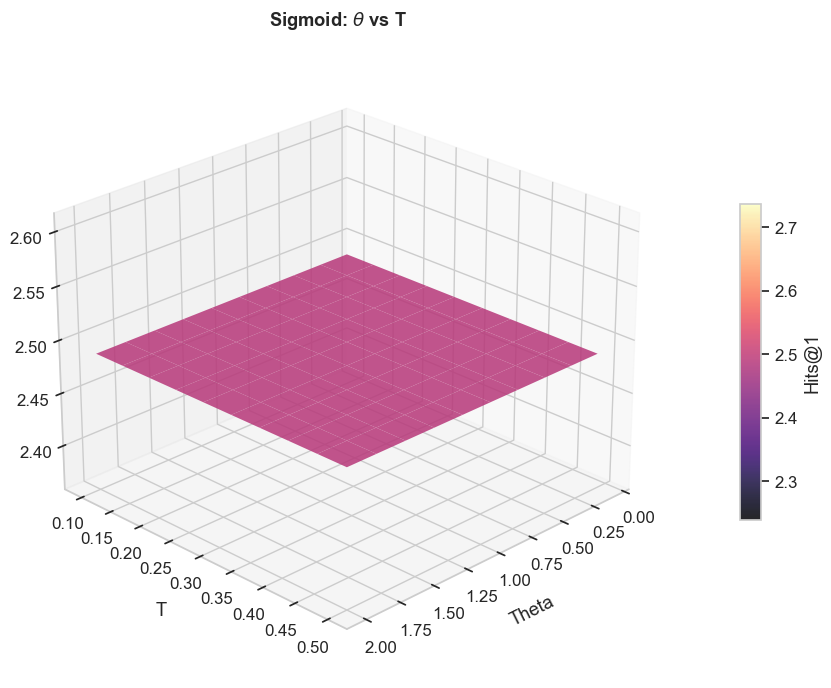

/tmp/ipykernel_459402/3761642831.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


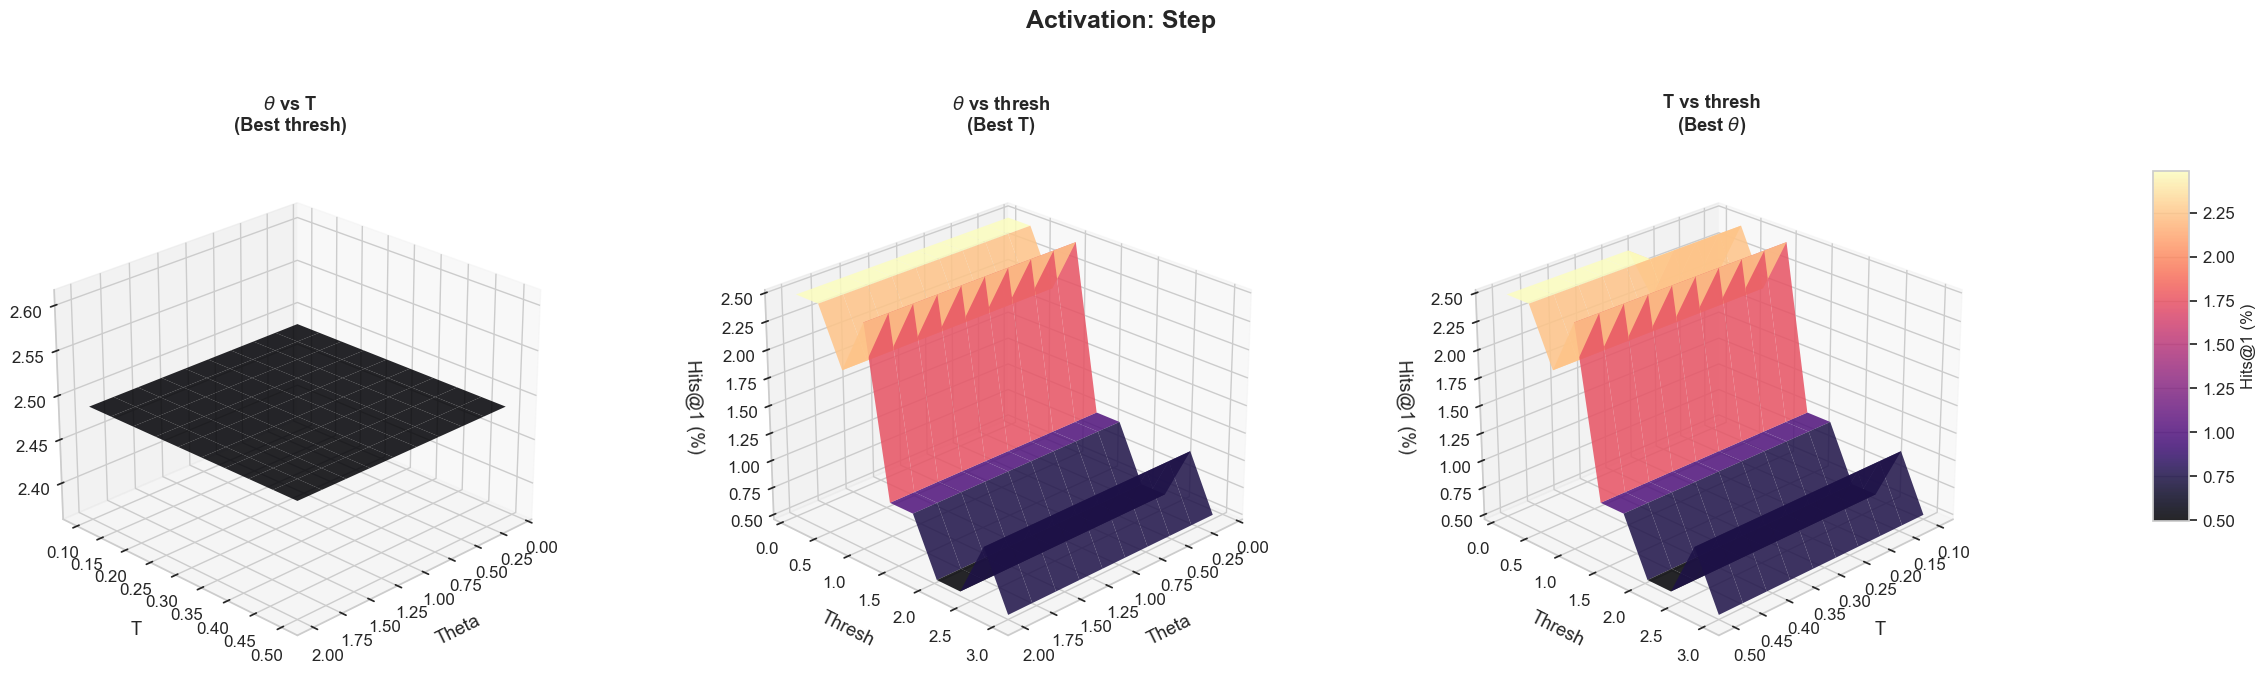

/tmp/ipykernel_459402/3761642831.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


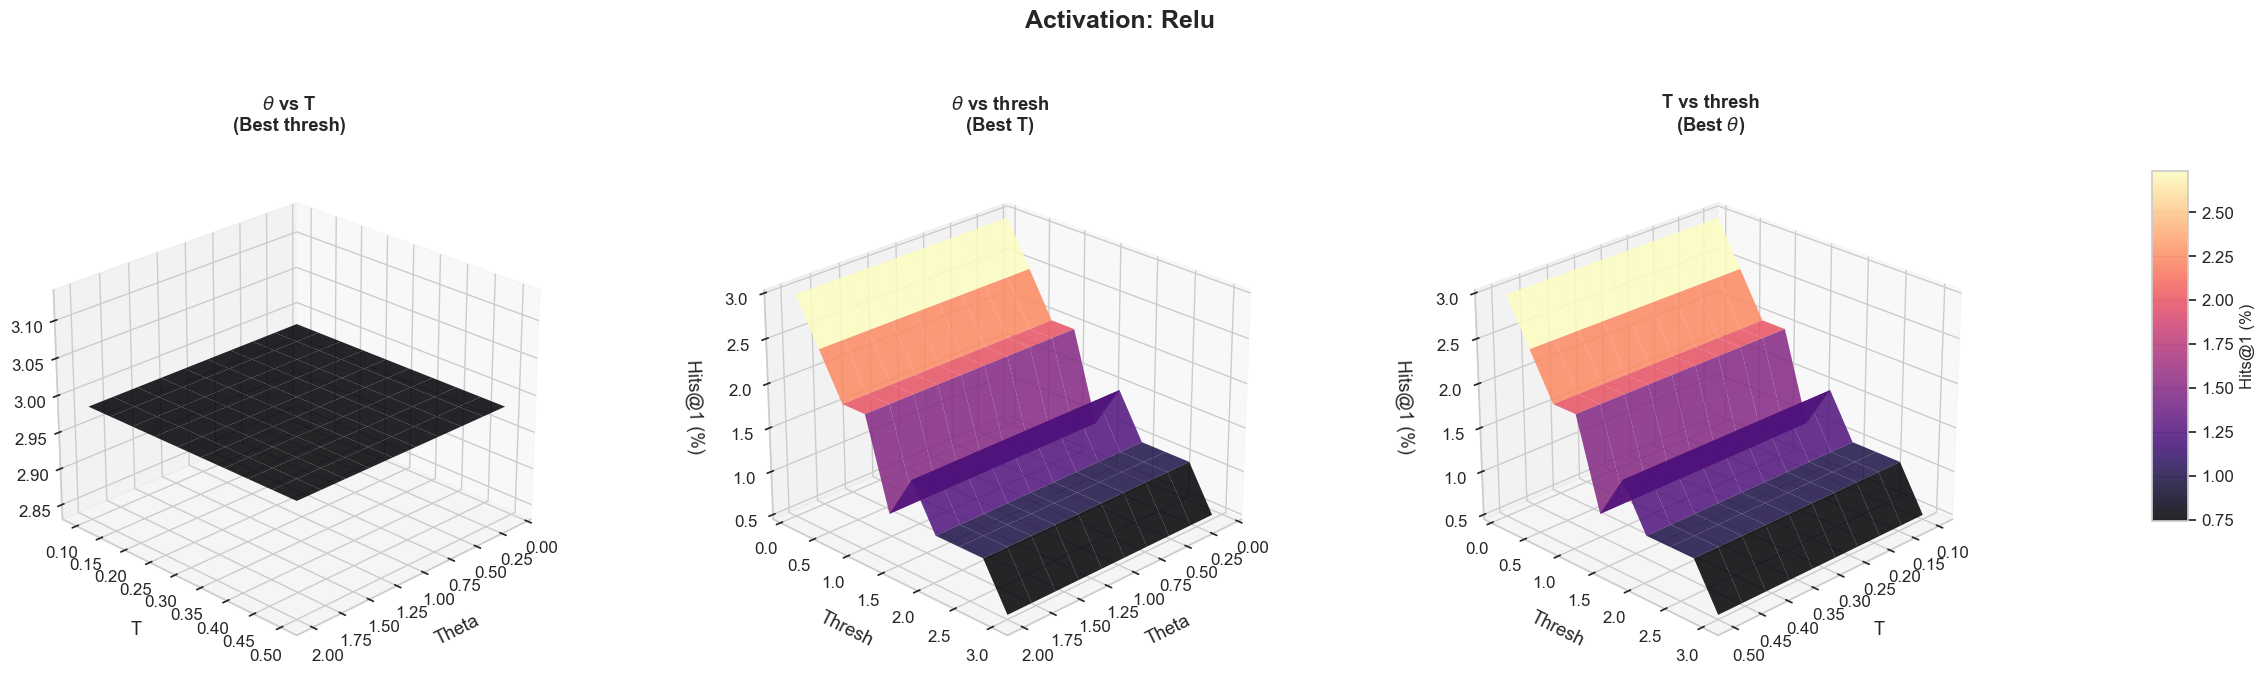

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 适用高级style与配色
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

sns.set_context("notebook", font_scale=1.1)

# 将搜索结果转为DataFrame
df = pd.DataFrame(all_search_results)

def plot_3d_surface(ax, data, x_col, y_col, z_col, title):
    # 根据 xy 聚合选择最佳的 z (对应“选择最佳thresh”等要求)
    agg_df = data.groupby([x_col, y_col], as_index=False)[z_col].max()
    
    # 转换为网格数据
    X_vals = np.sort(agg_df[x_col].unique())
    Y_vals = np.sort(agg_df[y_col].unique())
    X, Y = np.meshgrid(X_vals, Y_vals)
    Z = np.zeros_like(X)
    
    for i, x_v in enumerate(X_vals):
        for j, y_v in enumerate(Y_vals):
            # 取对应网格出的最佳 z 值
            val = agg_df[(agg_df[x_col] == x_v) & (agg_df[y_col] == y_v)]
            if len(val) > 0:
                Z[j, i] = val[z_col].values[0]
            else:
                Z[j, i] = np.nan
                
    # 绘制高级3D曲面，使用magma配色显得更加精美
    surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='none', alpha=0.85, antialiased=True)
    ax.set_xlabel(x_col.capitalize(), labelpad=10)
    ax.set_ylabel(y_col.capitalize(), labelpad=10)
    ax.set_zlabel('Hits@1 (%)', labelpad=10)
    ax.set_title(title, pad=15, fontweight='bold')
    
    # 视角优化
    ax.view_init(elev=25, azim=45)
    return surf

print("="*60)
print("开始渲染超参数搜索结果3D可视化...")
print("="*60)

# 1. Sigmoid 激活函数 (subplots(1, 1))
df_sig = df[df['activation'] == 'sigmoid']
if not df_sig.empty:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    surf = plot_3d_surface(ax, df_sig, 'theta', 'T', 'Hits@1', 'Sigmoid: $\\theta$ vs T')
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1)
    cbar.set_label('Hits@1')
    plt.tight_layout()
    plt.show()

# 2. Step 和 Relu 激活函数 (分别绘制 subplots(1, 3))
for act in ['step', 'relu']:
    df_act = df[df['activation'] == act]
    if df_act.empty:
        continue
        
    fig = plt.figure(figsize=(24, 7))
    fig.suptitle(f'Activation: {act.capitalize()}', fontsize=18, fontweight='bold', y=0.98)
    
    # Plot 1: theta vs T (最佳thresh)
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    surf1 = plot_3d_surface(ax1, df_act, 'theta', 'T', 'Hits@1', f'$\\theta$ vs T\n(Best thresh)')
    
    # Plot 2: theta vs thresh (最佳T)
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    surf2 = plot_3d_surface(ax2, df_act, 'theta', 'thresh', 'Hits@1', f'$\\theta$ vs thresh\n(Best T)')
    
    # Plot 3: T vs thresh (最佳theta)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    surf3 = plot_3d_surface(ax3, df_act, 'T', 'thresh', 'Hits@1', f'T vs thresh\n(Best $\\theta$)')
    
    # 添加一个统一的colorbar
    cbar_ax = fig.add_axes([0.93, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(surf3, cax=cbar_ax)
    cbar.set_label('Hits@1 (%)', fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

#### 超参数敏感度分析

In [7]:
import pandas as pd
import numpy as np

print("="*70)
print("超参数敏感度及影响深度分析")
print("="*70)

if 'all_search_results' in locals() and len(all_search_results) > 0:
    df_analysis = pd.DataFrame(all_search_results)
    
    # 1. 激活函数的影响
    print("\n[1] 激活函数 (Activation) 对性能的影响:")
    act_stats = df_analysis.groupby('activation')['Hits@1'].agg(['mean', 'max', 'min']).round(2)
    print(act_stats.to_string())
    best_act = act_stats['max'].idxmax()
    print(f"👉 结论: '{best_act}' 激活函数能达到最好的表现上限 (Max Hits@1 = {act_stats.loc[best_act, 'max']}%)。")
    
    # 2. Hebbian学习率(Theta)的影响
    print("\n[2] 关系聚类学习率 (Theta) 的影响:")
    theta_corr = df_analysis['theta'].corr(df_analysis['Hits@1'])
    print(f"  - Theta 与 Hits@1 的皮尔逊相关系数: {theta_corr:.4f}")
    
    # 对 Theta 进行区间划分观察均值
    try:
        df_analysis['theta_bin'] = pd.qcut(df_analysis['theta'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
        theta_stats = df_analysis.groupby('theta_bin', observed=True)['Hits@1'].mean().round(2)
        print("  - 不同 Theta 区间的平均 Hits@1:")
        print(f"    Low({df_analysis['theta'].min():.2f}~): {theta_stats.get('Low', 'N/A')}%, "
              f"Medium: {theta_stats.get('Medium', 'N/A')}%, "
              f"High(~{df_analysis['theta'].max():.2f}): {theta_stats.get('High', 'N/A')}%")
    except Exception as e:
        print("  - Theta区间均值计算跳过")

    # 3. 推理相关关系阈值(T)的影响
    print("\n[3] 关系相似度检索阈值 (T) 的影响:")
    T_corr = df_analysis['T'].corr(df_analysis['Hits@1'])
    print(f"  - T 与 Hits@1 的皮尔逊相关系数: {T_corr:.4f}")
    
    try:
        df_analysis['T_bin'] = pd.qcut(df_analysis['T'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
        T_stats = df_analysis.groupby('T_bin', observed=True)['Hits@1'].mean().round(2)
        print("  - 不同 T 区间的平均 Hits@1:")
        print(f"    Low({df_analysis['T'].min():.2f}~): {T_stats.get('Low', 'N/A')}%, "
              f"Medium: {T_stats.get('Medium', 'N/A')}%, "
              f"High(~{df_analysis['T'].max():.2f}): {T_stats.get('High', 'N/A')}%")
    except Exception as e:
        pass

    # 4. 激活函数阈值(Thresh)的影响 (仅过滤 step/relu)
    print("\n[4] 神经元激活阈值 (Thresh) 的影响 (限定 Step 和 Relu):")
    df_thresh = df_analysis[df_analysis['activation'].isin(['step', 'relu'])].copy()
    if not df_thresh.empty:
        thresh_corr = df_thresh['thresh'].corr(df_thresh['Hits@1'])
        print(f"  - Thresh 与 Hits@1 的皮尔逊相关系数: {thresh_corr:.4f}")
        try:
            df_thresh['thresh_bin'] = pd.qcut(df_thresh['thresh'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
            thresh_stats = df_thresh.groupby('thresh_bin', observed=True)['Hits@1'].mean().round(2)
            print("  - 不同 Thresh 区间的平均 Hits@1:")
            print(f"    Low({df_thresh['thresh'].min():.2f}~): {thresh_stats.get('Low', 'N/A')}%, "
                  f"Medium: {thresh_stats.get('Medium', 'N/A')}%, "
                  f"High(~{df_thresh['thresh'].max():.2f}): {thresh_stats.get('High', 'N/A')}%")
        except:
            pass
            
   

else:
    print("未找到全局搜索结果变量 'all_search_results'，请确保前面的超参数搜索 Cell 已经运行。")

超参数敏感度及影响深度分析

[1] 激活函数 (Activation) 对性能的影响:
            mean   max   min
activation                  
relu        1.54  2.99  0.50
sigmoid     2.49  2.49  2.49
step        1.37  2.49  0.50
👉 结论: 'relu' 激活函数能达到最好的表现上限 (Max Hits@1 = 2.99%)。

[2] 关系聚类学习率 (Theta) 的影响:
  - Theta 与 Hits@1 的皮尔逊相关系数: -0.0000
  - 不同 Theta 区间的平均 Hits@1:
    Low(0.10~): 1.51%, Medium: 1.51%, High(~2.00): 1.51%

[3] 关系相似度检索阈值 (T) 的影响:
  - T 与 Hits@1 的皮尔逊相关系数: 0.0124
  - 不同 T 区间的平均 Hits@1:
    Low(0.10~): 1.49%, Medium: 1.52%, High(~0.50): 1.52%

[4] 神经元激活阈值 (Thresh) 的影响 (限定 Step 和 Relu):
  - Thresh 与 Hits@1 的皮尔逊相关系数: -0.8911
  - 不同 Thresh 区间的平均 Hits@1:
    Low(0.10~): 2.34%, Medium: 1.0%, High(~3.00): 0.75%


### New Inference Rule

In [8]:
# ===========================
# 细致分析：h_r_detect=1 究竟影响了哪些样本？
# ===========================

def analyze_hr_detect_impact(model, train_triplets, test_triplets, num_entities):
    """
    专门针对“训练集中已经存在 (h, r)”的情况（即 h_r_detect 真正作用的样本）
    对比 h_r_detect=0 和 h_r_detect=1 的排名变化。
    """
    # 找出训练集中存在的所有的 (h, r)
    train_hr_set = set([(h, r) for h, r, t in train_triplets])
    
    # 区分出 Test 中属于“Seen (h, r)”的测试用例
    seen_hr_tests = [(h, r, t) for (h, r, t) in test_triplets if (h, r) in train_hr_set]
    unseen_hr_tests = [(h, r, t) for (h, r, t) in test_triplets if (h, r) not in train_hr_set]
    
    print(f"总测试集大小: {len(test_triplets)}")
    print(f"其中训练集见过 (h, r) 的测试样本数 (受 h_r_detect 影响): {len(seen_hr_tests)}")
    print(f"其中训练集未见过 (h, r) 的测试样本数: {len(unseen_hr_tests)}\n")
    
    # 只评估 seen_hr_tests
    if len(seen_hr_tests) == 0:
        print("没有符合条件的测试样本！")
        return
        
    print("--- 针对【见过 (h, r)】样本的专门评估 (使用 Score Version 1) ---")
    
    # 评测 h_r_detect = 0
    results_off = evaluate_predictions(
        model, seen_hr_tests, id_to_entity, num_entities, k=[1, 3, 10], score_version=1, h_r_detect=0
    )
    print(f"[关闭 h_r_detect=0] MR: {results_off['MR']:.4f} | MRR: {results_off['MRR']:.4f} | Hits@1: {results_off['Hits@1']:.2f}% | Hits@3: {results_off['Hits@3']:.2f}%")
    
    # 评测 h_r_detect = 1
    results_on = evaluate_predictions(
        model, seen_hr_tests, id_to_entity, num_entities, k=[1, 3, 10], score_version=1, h_r_detect=1
    )
    print(f"[开启 h_r_detect=1] MR: {results_on['MR']:.4f} | MRR: {results_on['MRR']:.4f} | Hits@1: {results_on['Hits@1']:.2f}% | Hits@3: {results_on['Hits@3']:.2f}%\n")
    
    # 提取一些变差的 Case 进行深度分析
    worse_cases = []
    better_cases = []
    
    # 建立一个快速查找 train_hr_to_t 的字典，避免重复遍历 train_triplets
    from collections import defaultdict
    train_hr_to_t = defaultdict(list)
    for h, r, t in train_triplets:
        train_hr_to_t[(h, r)].append(t)
    
    for test_idx, (h_idx, r_idx, t_idx) in enumerate(seen_hr_tests):
        # 关闭时的排名
        pred_off = model.infer(h_idx, r_idx, score_version=1, h_r_detect=0)
        sorted_off = sorted(pred_off.items(), key=lambda x: x[1], reverse=True)
        rank_off = next(i for i, (e, s) in enumerate(sorted_off, 1) if e == t_idx)
        
        # 开启时的排名
        pred_on = model.infer(h_idx, r_idx, score_version=1, h_r_detect=1)
        sorted_on = sorted(pred_on.items(), key=lambda x: x[1], reverse=True)
        rank_on = next(i for i, (e, s) in enumerate(sorted_on, 1) if e == t_idx)
        
        # 统计训练集中当前 (h,r) 有多少个已知的目标
        num_known_t = len(train_hr_to_t[(h_idx, r_idx)])
        
        if rank_on > rank_off:
            worse_cases.append((h_idx, r_idx, t_idx, rank_off, rank_on, num_known_t))
        elif rank_on < rank_off:
            better_cases.append((h_idx, r_idx, t_idx, rank_off, rank_on, num_known_t))
            
    print(f"对比结果：开启 h_r_detect 后，有 {len(worse_cases)} 个样本排名【下降(变差)】， {len(better_cases)} 个样本排名【上升(变好)】。")
    print(f"看来你的直觉是{'正确' if len(worse_cases)>len(better_cases) else '错误'}的，h_r_detect=1 确实起到了反作用。")
    
    # --- 新增分析颗粒度：上升 vs 下降 样本的 train 中 known_t 数量对比 ---
    if worse_cases:
        avg_worse_t = sum(x[5] for x in worse_cases) / len(worse_cases)
        max_worse_t = max(x[5] for x in worse_cases)
        min_worse_t = min(x[5] for x in worse_cases)
        print(f"   => 【下降(变差)】的样本：其 (h,r) 在 train 中对应的已知目标数 平均为 {avg_worse_t:.2f} 个 (范围: {min_worse_t}~{max_worse_t})")
    if better_cases:
        avg_better_t = sum(x[5] for x in better_cases) / len(better_cases)
        max_better_t = max(x[5] for x in better_cases)
        min_better_t = min(x[5] for x in better_cases)
        print(f"   => 【上升(变好)】的样本：其 (h,r) 在 train 中对应的已知目标数 平均为 {avg_better_t:.2f} 个 (范围: {min_better_t}~{max_better_t})")
    
    if worse_cases:
        print("\n--- 抽取最多 3 个变差的 Case 进行人工观察 ---")
        for i, (h, r, t, roff, ron, num_t) in enumerate(worse_cases[:3]):
            h_name = id_to_entity.get(h, str(h))
            r_name = id_to_relation.get(r, str(r))
            t_name = id_to_entity.get(t, str(t))
            
            # 看看训练集里面该 (h,r) 指向了哪些已知的 T
            known_targets = [val_t for (val_h, val_r, val_t) in train_triplets if val_h == h and val_r == r]
            known_target_names = [id_to_entity.get(k_t, str(k_t)) for k_t in known_targets]
            
            print(f"Case {i+1}: 预测 ({h_name}, {r_name}, [目标:{t_name}])")
            print(f"   => 训练集中提过的已知目标 (已知 T): {known_target_names}")
            print(f"   => [关h_r] 正确答案排第 {roff} 名 | [开h_r] 正确答案排第 {ron} 名")

print("=> 开始详细分析 h_r_detect 对于见过的 (h, r) 组合的影响...")
analyze_hr_detect_impact(model_cluster, train_triplets, test_triplets, num_entities)

=> 开始详细分析 h_r_detect 对于见过的 (h, r) 组合的影响...
总测试集大小: 201
其中训练集见过 (h, r) 的测试样本数 (受 h_r_detect 影响): 186
其中训练集未见过 (h, r) 的测试样本数: 15

--- 针对【见过 (h, r)】样本的专门评估 (使用 Score Version 1) ---
[关闭 h_r_detect=0] MR: 5.2258 | MRR: 0.3528 | Hits@1: 15.59% | Hits@3: 40.32%
[开启 h_r_detect=1] MR: 8.3280 | MRR: 0.1417 | Hits@1: 0.00% | Hits@3: 5.91%

对比结果：开启 h_r_detect 后，有 136 个样本排名【下降(变差)】， 36 个样本排名【上升(变好)】。
看来你的直觉是正确的，h_r_detect=1 确实起到了反作用。
   => 【下降(变差)】的样本：其 (h,r) 在 train 中对应的已知目标数 平均为 4.81 个 (范围: 1~10)
   => 【上升(变好)】的样本：其 (h,r) 在 train 中对应的已知目标数 平均为 5.25 个 (范围: 1~11)

--- 抽取最多 3 个变差的 Case 进行人工观察 ---
Case 1: 预测 (brazil, commonbloc1, [目标:india])
   => 训练集中提过的已知目标 (已知 T): ['burma', 'egypt', 'israel', 'jordan']
   => [关h_r] 正确答案排第 4 名 | [开h_r] 正确答案排第 5 名
Case 2: 预测 (brazil, embassy, [目标:uk])
   => 训练集中提过的已知目标 (已知 T): ['egypt', 'india', 'netherlands', 'poland', 'usa', 'ussr']
   => [关h_r] 正确答案排第 8 名 | [开h_r] 正确答案排第 9 名
Case 3: 预测 (brazil, exports3, [目标:usa])
   => 训练集中提过的已知目标 (已知 T): ['netherlands', 'uk']
 

In [9]:
# ===========================
# 细致分析：h_r_detect=1/2 究竟影响了哪些样本？
# ===========================

def analyze_hr_detect_impact(model, train_triplets, test_triplets, num_entities, dict_id_to_entity, dict_id_to_relation):
    """
    专门针对“训练集中已经存在 (h, r)”的情况（即 h_r_detect 真正作用的样本）
    对比 h_r_detect=0、1 和 2 的排名变化。
    """
    # 找出训练集中存在的所有的 (h, r)
    train_hr_set = set([(h, r) for h, r, t in train_triplets])
    
    # 区分出 Test 中属于“Seen (h, r)”的测试用例
    seen_hr_samples = [(h, r, t) for (h, r, t) in test_triplets if (h, r) in train_hr_set]
    unseen_hr_samples = [(h, r, t) for (h, r, t) in test_triplets if (h, r) not in train_hr_set]
    
    print(f"总测试集大小: {len(test_triplets)}")
    print(f"其中训练集见过 (h, r) 的测试样本数 (受 h_r_detect 影响): {len(seen_hr_samples)}")
    print(f"其中训练集未见过 (h, r) 的测试样本数: {len(unseen_hr_samples)}\n")
    
    # 只评估 seen_hr_samples
    if len(seen_hr_samples) == 0:
        print("没有符合条件的测试样本！")
        return seen_hr_samples
        
    print("--- 针对【见过 (h, r)】样本的专门评估 (使用 Score Version 1) ---")
    
    # 评测 h_r_detect = 0
    results_off = evaluate_predictions(
        model, seen_hr_samples, dict_id_to_entity, num_entities, k=[1, 3, 10], score_version=1, h_r_detect=0
    )
    print(f"[关闭 h_r_detect=0] MR: {results_off['MR']:.4f} | MRR: {results_off['MRR']:.4f} | Hits@1: {results_off['Hits@1']:.2f}% | Hits@3: {results_off['Hits@3']:.2f}%")
    
    # 评测 h_r_detect = 1
    results_on1 = evaluate_predictions(
        model, seen_hr_samples, dict_id_to_entity, num_entities, k=[1, 3, 10], score_version=1, h_r_detect=1
    )
    print(f"[开启 h_r_detect=1 (实体全局传导版)] MR: {results_on1['MR']:.4f} | MRR: {results_on1['MRR']:.4f} | Hits@1: {results_on1['Hits@1']:.2f}% | Hits@3: {results_on1['Hits@3']:.2f}%")

    # 评测 h_r_detect = 2
    results_on2 = evaluate_predictions(
        model, seen_hr_samples, dict_id_to_entity, num_entities, k=[1, 3, 10], score_version=1, h_r_detect=2
    )
    print(f"[开启 h_r_detect=2 (Target<-All NxM版)] MR: {results_on2['MR']:.4f} | MRR: {results_on2['MRR']:.4f} | Hits@1: {results_on2['Hits@1']:.2f}% | Hits@3: {results_on2['Hits@3']:.2f}%\n")
    
    # 提取一些变差的 Case 进行深度分析 (以 h_r_detect=2 为例，比较 2 和 0)
    worse_cases = []
    better_cases = []
    
    for test_idx, (h_idx, r_idx, t_idx) in enumerate(seen_hr_samples):
        # 关闭时的排名 (0)
        pred_off = model.infer(h_idx, r_idx, score_version=1, h_r_detect=0)
        sorted_off = sorted(pred_off.items(), key=lambda x: x[1], reverse=True)
        rank_off = next(i for i, (e, s) in enumerate(sorted_off, 1) if e == t_idx)
        
        # 开启时的排名 (2)
        pred_on = model.infer(h_idx, r_idx, score_version=1, h_r_detect=2)
        sorted_on = sorted(pred_on.items(), key=lambda x: x[1], reverse=True)
        rank_on = next(i for i, (e, s) in enumerate(sorted_on, 1) if e == t_idx)
        
        if rank_on > rank_off:
            worse_cases.append((h_idx, r_idx, t_idx, rank_off, rank_on))
        elif rank_on < rank_off:
            better_cases.append((h_idx, r_idx, t_idx, rank_off, rank_on))
            
    print(f"对比结果：开启 h_r_detect=2 后 vs 0，有 {len(worse_cases)} 个样本排名【下降(变差)】， {len(better_cases)} 个样本排名【上升(变好)】。")
    
    if worse_cases:
        print("\n--- 抽取最多 3 个变差的 Case 进行人工观察 ---")
        for i, (h, r, t, roff, ron) in enumerate(worse_cases[:3]):
            h_name = dict_id_to_entity.get(h, str(h))
            r_name = dict_id_to_relation.get(r, str(r))
            t_name = dict_id_to_entity.get(t, str(t))
            
            # 看看训练集里面该 (h,r) 指向了哪些已知的 T
            known_targets = [val_t for (val_h, val_r, val_t) in train_triplets if val_h == h and val_r == r]
            known_target_names = [dict_id_to_entity.get(k_t, str(k_t)) for k_t in known_targets]
            
            print(f"Case {i+1}: 预测 ({h_name}, {r_name}, [目标:{t_name}])")
            print(f"   => 训练集中提过的已知目标 (已知 T): {known_target_names}")
            print(f"   => [关h_r] 正确答案排第 {roff} 名 | [开启 h_r_detect=2] 正确答案排第 {ron} 名")

    return seen_hr_samples

print("=> 开始详细分析 h_r_detect 对于见过的 (h, r) 组合的影响...")
seen_hr_tests_list = analyze_hr_detect_impact(model_cluster, train_triplets, test_triplets, num_entities, id_to_entity, id_to_relation)

=> 开始详细分析 h_r_detect 对于见过的 (h, r) 组合的影响...
总测试集大小: 201
其中训练集见过 (h, r) 的测试样本数 (受 h_r_detect 影响): 186
其中训练集未见过 (h, r) 的测试样本数: 15

--- 针对【见过 (h, r)】样本的专门评估 (使用 Score Version 1) ---
[关闭 h_r_detect=0] MR: 5.2258 | MRR: 0.3528 | Hits@1: 15.59% | Hits@3: 40.32%
[开启 h_r_detect=1 (实体全局传导版)] MR: 8.3280 | MRR: 0.1417 | Hits@1: 0.00% | Hits@3: 5.91%
[开启 h_r_detect=2 (Target<-All NxM版)] MR: 7.7043 | MRR: 0.1612 | Hits@1: 0.00% | Hits@3: 8.60%

对比结果：开启 h_r_detect=2 后 vs 0，有 125 个样本排名【下降(变差)】， 49 个样本排名【上升(变好)】。

--- 抽取最多 3 个变差的 Case 进行人工观察 ---
Case 1: 预测 (brazil, commonbloc1, [目标:india])
   => 训练集中提过的已知目标 (已知 T): ['burma', 'egypt', 'israel', 'jordan']
   => [关h_r] 正确答案排第 4 名 | [开启 h_r_detect=2] 正确答案排第 6 名
Case 2: 预测 (brazil, exports3, [目标:usa])
   => 训练集中提过的已知目标 (已知 T): ['netherlands', 'uk']
   => [关h_r] 正确答案排第 1 名 | [开启 h_r_detect=2] 正确答案排第 3 名
Case 3: 预测 (brazil, intergovorgs, [目标:cuba])
   => 训练集中提过的已知目标 (已知 T): ['egypt', 'india', 'indonesia', 'israel', 'netherlands', 'uk', 'usa']
   => [关h_r] 正确答

正在提取统计特征指标...

特征指标 (Mean / Median)                | 排名变好组 (49例)             | 排名变差组 (125例)           
----------------------------------------------------------------------------------------
1. Query在训练集中已有目标数(T)              | 均值:  4.8 (中位:  5.0)    | 均值:  5.0 (中位:  5.0)   
2. 正确答案(T)在当前关系活跃边数                | 均值: 10.3 (中位: 11.0)    | 均值:  9.4 (中位: 10.0)   
3. 正确答案与已知T质心的相似度                  | 均值: 0.7 (中位: 0.7)      | 均值: 0.5 (中位: 0.6)     


/tmp/ipykernel_459402/3914339743.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=['Better', 'Worse'], patch_artist=True)
/tmp/ipykernel_459402/3914339743.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=['Better', 'Worse'], patch_artist=True)
/tmp/ipykernel_459402/3914339743.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=['Better', 'Worse'], patch_artist=True)


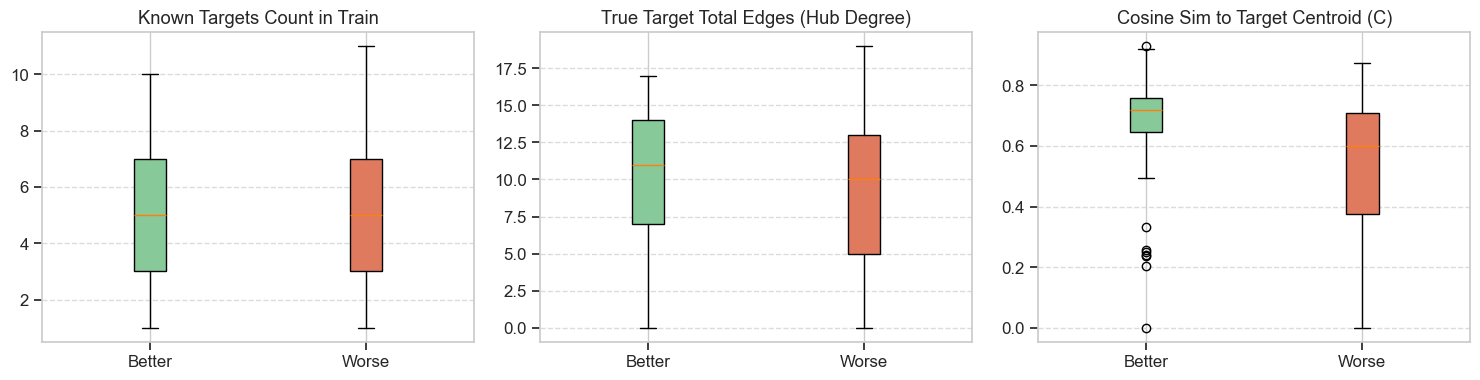

In [12]:
# ==========================================
# 分析“变好”的样本与“变坏”的样本的【集体特征】
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def analyze_collective_characteristics(model, better_cases, worse_cases, train_triplets, num_entities):
    def get_V_N(ent_idx, r_idx):
        src = model._vec_index(ent_idx, r_idx)
        tg = [model._vec_index(i, r_idx) for i in range(num_entities)]
        return np.concatenate([model.W_beta_beta[tg, src], model.W_beta_beta[src, tg]])

    def extract_metrics(cases):
        known_t_counts = []
        target_degrees = []
        cos_sims = []
        
        for case in cases:
            # 兼容不同长度提取的 case (只取前三个：h, r, t)
            h_idx, r_idx, t_idx = case[0], case[1], case[2]
            
            # 1. 训练集中已知目标的数量
            known_targets = [t for (val_h, val_r, t) in train_triplets if val_h == h_idx and val_r == r_idx]
            known_t_counts.append(len(known_targets))
            
            # 2. 真实目标节点的度 (在当前关系作为头/尾的连边总数，体现活跃度)
            target_V = get_V_N(t_idx, r_idx)
            target_degrees.append(np.sum(target_V > 0)) 
            
            # 3. Target与已知网络目标质心C的余弦相似度
            if len(known_targets) > 0:
                V_known = [get_V_N(t, r_idx) for t in known_targets]
                C_combined = np.mean(V_known, axis=0)
                norm_t = np.linalg.norm(target_V)
                norm_c = np.linalg.norm(C_combined)
                sim = np.dot(target_V, C_combined) / (norm_t * norm_c) if norm_t > 0 and norm_c > 0 else 0
            else:
                sim = 0
            cos_sims.append(sim)
            
        return {
            'known_T_counts': np.array(known_t_counts),
            'target_degrees': np.array(target_degrees),
            'cos_sims': np.array(cos_sims)
        }

    print("正在提取统计特征指标...")
    metrics_better = extract_metrics(better_cases)
    metrics_worse = extract_metrics(worse_cases)

    # =============== 打印文字表格 ===============
    print(f"\n{'特征指标 (Mean / Median)':<35} | {'排名变好组 (' + str(len(better_cases)) + '例)':<23} | {'排名变差组 (' + str(len(worse_cases)) + '例)':<23}")
    print("-" * 88)
    
    def print_stat(name, key, is_int=False):
        fmt = "{:>5.1f}" if not is_int else "{:>4.1f}"
        mean_b = np.mean(metrics_better[key]) if len(metrics_better[key])>0 else 0
        mean_w = np.mean(metrics_worse[key]) if len(metrics_worse[key])>0 else 0
        median_b = np.median(metrics_better[key]) if len(metrics_better[key])>0 else 0
        median_w = np.median(metrics_worse[key]) if len(metrics_worse[key])>0 else 0
        
        b_str = f"均值:{fmt.format(mean_b)} (中位:{fmt.format(median_b)})"
        w_str = f"均值:{fmt.format(mean_w)} (中位:{fmt.format(median_w)})"
        print(f"{name:<34} | {b_str:<22} | {w_str:<22}")

    print_stat("1. Query在训练集中已有目标数(T)", "known_T_counts")
    print_stat("2. 正确答案(T)在当前关系活跃边数", "target_degrees")
    print_stat("3. 正确答案与已知T质心的相似度", "cos_sims", is_int=True)
    
    # =============== 绘制对比箱线图 ===============
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    colors = ['#88c999', '#e07a5f'] # better: green, worse: red
    
    def plot_box(ax, data, title):
        bplot = ax.boxplot(data, labels=['Better', 'Worse'], patch_artist=True)
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
        ax.set_title(title)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plot_box(axes[0], [metrics_better['known_T_counts'], metrics_worse['known_T_counts']], 'Known Targets Count in Train')
    plot_box(axes[1], [metrics_better['target_degrees'], metrics_worse['target_degrees']], 'True Target Total Edges (Hub Degree)')
    plot_box(axes[2], [metrics_better['cos_sims'], metrics_worse['cos_sims']], 'Cosine Sim to Target Centroid (C)')
    
    plt.tight_layout()
    plt.show()

# 因为之前生成 worse_cases 的时候可能在可视化单元格里定义为了 worse_cases_full，这里做一个捕捉和调用
try:
    if 'worse_cases_full' not in locals():
        # 如果未定义，我们重新算一次
        print("重新跑一遍打分收集 better/worse cases...")
        train_hr_set = set([(h, r) for h, r, t in train_triplets])
        v_seen = [(h, r, t) for (h, r, t) in test_triplets if (h, r) in train_hr_set]
        bc_full, wc_full = [], []
        for b_h_idx, b_r_idx, b_t_idx in v_seen:
            pred_off_s = model_cluster.infer(b_h_idx, b_r_idx, score_version=1, h_r_detect=0)
            pred_on_s = model_cluster.infer(b_h_idx, b_r_idx, score_version=1, h_r_detect=2)
            r_off = next(i for i, (e, s) in enumerate(sorted(pred_off_s.items(), key=lambda x:x[1], reverse=True), 1) if e == b_t_idx)
            r_on = next(i for i, (e, s) in enumerate(sorted(pred_on_s.items(), key=lambda x:x[1], reverse=True), 1) if e == b_t_idx)
            if r_on < r_off: bc_full.append((b_h_idx, b_r_idx, b_t_idx, r_off, r_on))
            elif r_on > r_off: wc_full.append((b_h_idx, b_r_idx, b_t_idx, r_off, r_on))
        better_cases_full = bc_full
        worse_cases_full = wc_full
        
    if better_cases_full and worse_cases_full:
        analyze_collective_characteristics(model_cluster, better_cases_full, worse_cases_full, train_triplets, num_entities)
    else:
        print("数量不足，无法分析特征。")
except Exception as e:
    print("发生错误:", e)

#### *确保$\mathbf{C}_{(\alpha^k,\gamma_j)}$代码层面是没问题的

In [11]:
def analyze_28D_vector(model, ent_name, rel_name, dict_id_to_entity, dict_entity_to_id, dict_relation_to_id, train_triplets):
    ent_idx = dict_entity_to_id[ent_name]
    r_idx = dict_relation_to_id[rel_name]
    
    # 1. 提取28维向量
    src = model._vec_index(ent_idx, r_idx)
    tg = [model._vec_index(i, r_idx) for i in range(model.num_entities)]
    
    # v_out: model.W_beta_beta[tg, src], v_in: model.W_beta_beta[src, tg]
    v_out = model.W_beta_beta[tg, src]
    v_in = model.W_beta_beta[src, tg]
    v_28 = np.concatenate([v_out, v_in])
    
    print(f"==================================================")
    print(f"28维特征向量 [{ent_name}, {rel_name}]:")
    print(v_28)
    print(f"==================================================\n")
    
    # 建立训练集的对照查表
    train_set = set([(h, r, t) for h, r, t in train_triplets])
    
    print(f"{'索引':<4} | {'向量值':<6} | {'物理含义':<35} | {'训练集实际情况':<15} | {'是否对齐'}")
    print("-" * 85)
    
    num_ent = model.num_entities
    all_aligned = True
    
    for i in range(28):
        val = v_28[i]
        if i < num_ent:
            # v_out部分
            target_ent = dict_id_to_entity[i]
            meaning = f"{ent_name} --[{rel_name}]--> {target_ent}"
            true_exists = (ent_idx, r_idx, i) in train_set
            part = "v_out"
        else:
            # v_in部分
            source_ent = dict_id_to_entity[i - num_ent]
            meaning = f"{source_ent} --[{rel_name}]--> {ent_name}"
            true_exists = (i - num_ent, r_idx, ent_idx) in train_set
            part = "v_in"
        
        # 判断阈值 (>0 则认为激活)
        val_bool = (val > 0.5) 
        aligned = (val_bool == true_exists)
        if not aligned:
            all_aligned = False
            
        print(f"{i:<4} | {val:<6.1f} | {meaning:<35} | {'连边存在' if true_exists else '不存在':<15} | {'✅ 完全对齐' if aligned else '❌ 错位'}")
        
    print("-" * 85)
    if all_aligned:
        print("结论：28维向量的每一个位置都与训练集中的真实图谱网络完美对齐！")
    else:
        print("结论：发现不对齐的情况，请检查维度构建！")

analyze_28D_vector(model_cluster, 'usa', 'commonbloc1', id_to_entity, entity_to_id, relation_to_id, train_triplets)

28维特征向量 [usa, commonbloc1]:
[0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0.
 0. 0. 0. 0.]

索引   | 向量值    | 物理含义                                | 训练集实际情况         | 是否对齐
-------------------------------------------------------------------------------------
0    | 0.0    | usa --[commonbloc1]--> brazil       | 不存在             | ✅ 完全对齐
1    | 1.0    | usa --[commonbloc1]--> burma        | 连边存在            | ✅ 完全对齐
2    | 0.0    | usa --[commonbloc1]--> china        | 不存在             | ✅ 完全对齐
3    | 0.0    | usa --[commonbloc1]--> cuba         | 不存在             | ✅ 完全对齐
4    | 1.0    | usa --[commonbloc1]--> egypt        | 连边存在            | ✅ 完全对齐
5    | 1.0    | usa --[commonbloc1]--> india        | 连边存在            | ✅ 完全对齐
6    | 1.0    | usa --[commonbloc1]--> indonesia    | 连边存在            | ✅ 完全对齐
7    | 1.0    | usa --[commonbloc1]--> israel       | 连边存在            | ✅ 完全对齐
8    | 1.0    | usa --[commonbloc1]--> jordan       | 连边存在            | ✅ 完全对齐
9    | 0.0

## Other Models On $\texttt{NATONS}$

In [13]:
# ===========================
# 测试其他模型在Nations数据集上的性能
# ===========================

import torch
import torch.optim as optim
import time
from pykeen.triples import TriplesFactory
from pykeen.training import SLCWATrainingLoop
from pykeen.evaluation import RankBasedEvaluator
from pykeen.models import (
    TransE, TransH, TransR, TransD, 
    DistMult, ConvE, RotatE, ComplEx, HolE, 
    RESCAL, SimplE, TuckER, ERMLP
)

def create_train_test_factories(dataset, use_inverse=False):
    """
    从Nations数据集创建train和test的TriplesFactory
    
    Args:
        dataset: PyKEEN Nations数据集
        use_inverse: 是否创建inverse triples
        
    Returns:
        train_set, test_set: PyKEEN TriplesFactory对象
    """
    train_set = TriplesFactory(
        mapped_triples=dataset.training.mapped_triples,
        entity_to_id=dataset.training.entity_to_id,
        relation_to_id=dataset.training.relation_to_id,
        create_inverse_triples=use_inverse,
    )
    
    test_set = TriplesFactory(
        mapped_triples=dataset.testing.mapped_triples,
        entity_to_id=dataset.training.entity_to_id,
        relation_to_id=dataset.training.relation_to_id,
        create_inverse_triples=False,
    )
    
    return train_set, test_set

def evaluate_model_pykeen(model, test_set, k_values=[1, 3, 10]):
    """
    使用PyKEEN的evaluator评估模型
    
    Args:
        model: PyKEEN模型
        test_set: 测试TriplesFactory
        k_values: 计算Hits@k的k值列表
        
    Returns:
        results: 评估指标字典
    """
    # 创建evaluator
    evaluator = RankBasedEvaluator()
    
    # 进行评估
    metrics = evaluator.evaluate(
        model=model,
        mapped_triples=test_set.mapped_triples,
        batch_size=128,
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    )
    
    results = {
        'MR': metrics.get_metric('mean_rank'),
        'MRR': metrics.get_metric('mean_reciprocal_rank'),
    }
    
    for k in k_values:
        hits_at_k_key = f'hits@{k}'
        results[f'Hits@{k}'] = metrics.get_metric(hits_at_k_key) * 100  # 转换为百分比
    
    return results

print("="*70)
print("开始测试不同模型在Nations数据集上的性能")
print("="*70)

# 获取设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}\n")

# 定义要测试的模型列表
# (model_name, model_class, model_kwargs, use_inverse)
# 包含大多主流和经典的代表性图表示学习模型
models_to_test = [
    ('TransE', TransE, {'embedding_dim': 50}, False),
    ('TransH', TransH, {'embedding_dim': 50}, False),
    ('TransR', TransR, {'embedding_dim': 50, 'relation_dim': 50}, False),
    ('TransD', TransD, {'embedding_dim': 50, 'relation_dim': 50}, False),
    ('DistMult', DistMult, {'embedding_dim': 50}, False),
    ('ComplEx', ComplEx, {'embedding_dim': 50}, False),
    ('HolE', HolE, {'embedding_dim': 50}, False),
    ('RESCAL', RESCAL, {'embedding_dim': 50}, False),
    ('SimplE', SimplE, {'embedding_dim': 50}, False),
    ('TuckER', TuckER, {'embedding_dim': 50}, False),
    ('ERMLP', ERMLP, {'embedding_dim': 50}, False),
    ('ConvE', ConvE, {'embedding_dim': 50}, True),  # ConvE需要inverse triples
    ('RotatE', RotatE, {'embedding_dim': 50}, False),
]

# 存储所有结果
all_results = {}

# 将您的 RR net 的结果手动汇入到图谱模型对比库当中
all_results['RR net'] = {
    'results': {
        'MR': 5.5771,
        'MRR': 0.3426,
        'Hits@1': 16.42,
        'Hits@3': 35.32,
        'Hits@10': 86.07
    },
    'training_time': '-'
}

# 确保数据集加载
dataset, entity_to_id, relation_to_id = load_nations_data()

# 训练和评估每个模型
for model_name, model_class, model_kwargs, use_inverse in models_to_test:
    print("="*70)
    print(f"测试模型: {model_name}")
    print("="*70)
    
    try:
        # 创建train和test factories
        print(f"创建TriplesFactory (use_inverse={use_inverse})...")
        train_set, test_set = create_train_test_factories(dataset, use_inverse=use_inverse)
        
        # 创建模型
        print(f"创建{model_name}模型...")
        model = model_class(
            triples_factory=train_set,
            **model_kwargs
        )
        model = model.to(device)
        print(f"模型创建成功")
        
        # 训练
        print(f"训练{model_name}...")
        start_time = time.time()
        
        # 创建优化器
        optimizer = optim.Adagrad(model.parameters(), lr=0.001)
        
        # 创建训练循环
        training_loop = SLCWATrainingLoop(
            model=model,
            triples_factory=train_set,
            optimizer=optimizer,
            negative_sampler='basic',
        )
        
        # 训练（使用较少epoch以加快速度）
        training_loop.train(
            num_epochs=50,
            batch_size=32,
            triples_factory=train_set,
        )
        
        training_time = time.time() - start_time
        print(f"训练耗时: {training_time:.2f}秒")
        
        # 评估
        print(f"评估{model_name}在测试集上的性能...")
        results = evaluate_model_pykeen(model, test_set)
        
        all_results[model_name] = {
            'results': results,
            'training_time': round(training_time, 2)
        }
        
        # 打印结果
        print(f"\n{model_name}的测试结果:")
        print(f"  Mean Rank (MR): {results['MR']:.4f}")
        print(f"  Mean Reciprocal Rank (MRR): {results['MRR']:.4f}")
        print(f"  Hits@1: {results['Hits@1']:.2f}%")
        print(f"  Hits@3: {results['Hits@3']:.2f}%")
        print(f"  Hits@10: {results['Hits@10']:.2f}%")
        print(f"  Training Time: {training_time:.2f}s\n")
        
        # 清理GPU内存
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"❌ 错误: 训练{model_name}时出错")
        print(f"错误信息: {str(e)}\n")
        import traceback
        traceback.print_exc()
        print()

# 生成对比总结
print("\n" + "="*70)
print("所有模型的性能对比总结")
print("="*70 + "\n")

if all_results:
    # 创建对比表
    import pandas as pd
    
    comparison_data = []
    for model_name, model_info in all_results.items():
        results = model_info['results']
        
        time_val = model_info['training_time']
        time_str = f"{time_val:.2f}" if isinstance(time_val, (int, float)) else str(time_val)
        
        comparison_data.append({
            'Model': model_name,
            'MR': f"{results['MR']:.4f}",
            'MRR': f"{results['MRR']:.4f}",
            'Hits@1': f"{results['Hits@1']:.2f}%",
            'Hits@3': f"{results['Hits@3']:.2f}%",
            'Hits@10': f"{results['Hits@10']:.2f}%",
            'Training Time(s)': time_str,
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    
    # 找出最佳模型
    print(f"\n{'='*70}")
    print("模型排名（基于MRR）:")
    print(f"{'='*70}")
    
    mrr_ranking = sorted(all_results.items(), 
                        key=lambda x: x[1]['results']['MRR'], 
                        reverse=True)
    
    for rank, (model_name, model_info) in enumerate(mrr_ranking, 1):
        mrr = model_info['results']['MRR']
        # 加上高亮标记展示RR net
        star = "⭐ " if model_name == "RR net" else "   "
        print(f"{star}{rank}. {model_name:<10}: MRR = {mrr:.4f}")
    
    print()

print("="*70)
print("模型测试完成！")
print("="*70)

No random seed is specified. This may lead to non-reproducible results.


开始测试不同模型在Nations数据集上的性能
使用设备: cuda

实体总数: 14
关系总数: 55
测试模型: TransE
创建TriplesFactory (use_inverse=False)...
创建TransE模型...
模型创建成功
训练TransE...


Training epochs on cuda:0: 100%|██████████| 50/50 [00:08<00:00,  5.66epoch/s, loss=1.32, prev_loss=1.23]
The filtered setting was enabled, but there were no `additional_filter_triples`
given. This means you probably forgot to pass (at least) the training triples. Try:

    additional_filter_triples=[dataset.training.mapped_triples]

Or if you want to use the Bordes et al. (2013) approach to filtering, do:

    additional_filter_triples=[
        dataset.training.mapped_triples,
        dataset.validation.mapped_triples,
    ]



训练耗时: 9.04秒
评估TransE在测试集上的性能...


Evaluating on cuda:0: 100%|██████████| 201/201 [00:00<00:00, 3.66ktriple/s]
No random seed is specified. This may lead to non-reproducible results.


...


ConvE的测试结果:
  Mean Rank (MR): 6.6393
  Mean Reciprocal Rank (MRR): 0.2598
  Hits@1: 8.71%
  Hits@3: 25.62%
  Hits@10: 82.59%
  Training Time: 17.54s

测试模型: RotatE
创建TriplesFactory (use_inverse=False)...
创建RotatE模型...
模型创建成功
训练RotatE...


Training epochs on cuda:0: 100%|██████████| 50/50 [00:11<00:00,  4.28epoch/s, loss=0.955, prev_loss=0.951]
The filtered setting was enabled, but there were no `additional_filter_triples`
given. This means you probably forgot to pass (at least) the training triples. Try:

    additional_filter_triples=[dataset.training.mapped_triples]

Or if you want to use the Bordes et al. (2013) approach to filtering, do:

    additional_filter_triples=[
        dataset.training.mapped_triples,
        dataset.validation.mapped_triples,
    ]



训练耗时: 11.78秒
评估RotatE在测试集上的性能...


Evaluating on cuda:0: 100%|██████████| 201/201 [00:00<00:00, 12.3ktriple/s]


RotatE的测试结果:
  Mean Rank (MR): 6.3856
  Mean Reciprocal Rank (MRR): 0.2924
  Hits@1: 11.44%
  Hits@3: 31.59%
  Hits@10: 80.60%
  Training Time: 11.78s


所有模型的性能对比总结

   Model     MR    MRR Hits@1 Hits@3 Hits@10 Training Time(s)
  RR net 5.5771 0.3426 16.42% 35.32%  86.07%                -
  TransE 7.7736 0.1788  0.00% 16.17%  70.65%             9.04
  TransH 7.5871 0.1804  0.00% 16.42%  74.88%            13.20
  TransR 6.9627 0.2529  7.96% 26.87%  76.87%            13.90
  TransD 7.0025 0.2061  0.00% 24.63%  79.35%            14.17
DistMult 6.9328 0.2692 10.20% 26.12%  74.63%             9.45
 ComplEx 6.9080 0.2553  9.20% 24.38%  79.35%            11.95
    HolE 7.2512 0.2505  8.96% 23.63%  73.88%            11.27
  RESCAL 6.7264 0.2717 11.44% 25.87%  81.09%            14.11
  SimplE 7.6294 0.2083  4.98% 17.41%  73.38%            10.30
  TuckER 7.6045 0.2173  5.72% 18.66%  73.13%            11.71
   ERMLP 6.4776 0.2903 11.69% 29.60%  80.10%             8.83
   ConvE 6.6393 0.2598  8.7